In [1]:
# Configuracion inicial
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de UI moderna para las gráficas (Dark mode + Esmeralda)
plt.style.use('dark_background')
sns.set_palette(sns.color_palette(["#2ecc71", "#f5f5dc", "#e74c3c", "#3498db"]))
plt.rcParams.update({
    'axes.facecolor': '#121212',
    'figure.facecolor': '#121212',
    'grid.color': '#333333',
    'text.color': '#f5f5dc',
    'axes.labelcolor': '#f5f5dc',
    'xtick.color': '#f5f5dc',
    'ytick.color': '#f5f5dc'
})

import warnings
warnings.filterwarnings('ignore')

In [31]:
# Descometnar las lineas de abajo para descargar el dataset originalmente desde Kaggle.
path = kagglehub.dataset_download("ashishkumarak/play-store-reviews-facebook")

print("Path to dataset files:", path)

Path to dataset files: /home/iandi/.cache/kagglehub/datasets/ashishkumarak/play-store-reviews-facebook/versions/739


In [2]:
df_crudo = pd.read_csv("./data/facebook_reviews.csv")
print("Dimensiones del dataset:", df_crudo.shape)
df_crudo.head()

Dimensiones del dataset: (355773, 8)


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,28d4c82d-a63c-4c27-8eaa-9fdb2b08073e,Adeel Virk,"I used Facebook for selling local products, an...",4,1,559.1.0.52.72,2026-05-07 01:43:34,559.1.0.52.72
1,23a5309b-f8f3-44ab-bf74-cf92a2dad20c,Roger Blair,I'm not receiving notifications on Facebook li...,1,3,559.1.0.52.72,2026-05-07 00:14:13,559.1.0.52.72
2,134d44f1-4366-4149-a4cc-e6d1e181f59c,Rabia Shaheen W/O Salahuddin khilji (Bia khilji),I used Facebook mainly for selling local produ...,1,0,558.0.0.70.72,2026-05-07 01:22:52,558.0.0.70.72
3,16d717cf-47d9-45e9-8e48-eca0dae27260,paul mcnabb,"its all a pay to play now, robs you of views a...",1,0,557.0.0.59.72,2026-05-07 01:55:17,557.0.0.59.72
4,ece2af88-e766-4a00-8735-cfd1066cac22,Katmar Berg,My admin account was wrongfully disabled after...,1,0,559.1.0.52.72,2026-05-07 01:24:10,559.1.0.52.72


In [3]:
# Análisis de Valores Nulos
nulos = df_crudo.isnull().sum()
nulos_porcentaje = (nulos / len(df_crudo)) * 100

df_nulos = pd.DataFrame({'Valores Faltantes': nulos, 'Porcentaje (%)': nulos_porcentaje})
display(df_nulos[df_nulos['Valores Faltantes'] > 0].sort_values(by='Porcentaje (%)', ascending=False))

,Valores Faltantes,Porcentaje (%)
appVersion,62481,17.562041
reviewCreatedVersion,62481,17.562041
content,34,0.009557
userName,3,0.000843


Podemos notar que el dataset es bastante grande, por temas de ahorro de recursos de computo y tiempo (memoria, cpu, etc...).
Estaremos utilizando una muestra de 50,000 datos unicamente para el desarrollo del proyecto de este mismo dataset.
En la etapa final aplicaremos todo el procedimiento con el dataset entero para mostrar los resultados.

In [4]:
# 1. Tomar muestra representativa de 50k
# df_muestra = df_crudo.sample(n=50000, random_state=42).reset_index(drop=True)

# Ahora estaremos usando el dataset completo una vez que hemos terminado las pruebas con la muestra.
df_muestra = df_crudo.copy()

# 2. Eliminar reseñas sin texto
df_muestra = df_muestra.dropna(subset=['content'])

# 3. Eliminar columnas innecesarias
# Mantenemos 'score', 'content', 'appVersion' y 'at'
columnas_a_eliminar = ['reviewId', 'userName', 'thumbsUpCount', 'reviewCreatedVersion']
df_muestra = df_muestra.drop(columns=columnas_a_eliminar, errors='ignore')

print("Dimensiones después de limpiar nulos y columnas:", df_muestra.shape)
display(df_muestra.head(3))

Dimensiones después de limpiar nulos y columnas: (355739, 4)


,content,score,at,appVersion
0,"I used Facebook for selling local products, an...",4,2026-05-07 01:43:34,559.1.0.52.72
1,I'm not receiving notifications on Facebook li...,1,2026-05-07 00:14:13,559.1.0.52.72
2,I used Facebook mainly for selling local produ...,1,2026-05-07 01:22:52,558.0.0.70.72


In [ ]:
# Importar la función de limpieza del corpus desde script utils/cleaner
from utils.cleaner import procesar_corpus

print("Iniciando detección de idioma y limpieza...")
df_limpio = procesar_corpus(df_muestra, 'content')

# evitar reprocesar
df_limpio.to_csv('./data/facebook_reviews_limpio_completo.csv', index=False)

print(f"Procesamiento finalizado. Filas retenidas: {df_limpio.shape[0]} / {df_muestra.shape[0]}")
display(df_limpio[['content', 'texto_limpio']].head())

Iniciando detección de idioma y limpieza...
Procesamiento finalizado. Filas retenidas: 121424 / 355739


,content,texto_limpio
0,"I used Facebook for selling local products, an...",i used facebook for selling local products and...
1,I'm not receiving notifications on Facebook li...,im not receiving notifications on facebook lik...
2,I used Facebook mainly for selling local produ...,i used facebook mainly for selling local produ...
3,"its all a pay to play now, robs you of views a...",its all a pay to play now robs you of views an...
4,My admin account was wrongfully disabled after...,my admin account was wrongfully disabled after...


A partir de aqui, tenemos un dataset limpio y listo para continuar, se puede cargar el dataset ubicado en:
`./data/facebook_reviews_limpio_50k.csv`

In [3]:
# si el dataset no esta cargado, cargarlo desde el csv limpio
df_limpio = pd.read_csv('./data/facebook_reviews_limpio_completo.csv')

# Mapeo de la calificación real (para análisis comparativo mas adelante)
def asignar_polaridad(score):
    if score <= 2:
        return 'Negativo'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positivo'

df_limpio['sentimiento_real'] = df_limpio['score'].apply(asignar_polaridad)

# Filtramos las reseñas neutrales para mantener un análisis polarizado estricto
df_analisis = df_limpio[df_limpio['sentimiento_real'] != 'Neutral'].copy()

# 2. Aplicar AFINN
from utils.sentiment_engine import aplicar_analisis_sentimiento

print("Calculando polaridad con AFINN...")
df_resultados = aplicar_analisis_sentimiento(df_analisis, 'texto_limpio')

display(df_resultados[['texto_limpio', 'score', 'sentimiento_real', 'sentimiento_predicho']].head())

Calculando polaridad con AFINN...


,texto_limpio,score,sentimiento_real,sentimiento_predicho
0,i used facebook for selling local products and...,4,Positivo,Negativo
1,im not receiving notifications on facebook lik...,1,Negativo,Neutral
2,i used facebook mainly for selling local produ...,1,Negativo,Positivo
3,its all a pay to play now robs you of views an...,1,Negativo,Negativo
4,my admin account was wrongfully disabled after...,1,Negativo,Negativo


Precisión del modelo AFINN: 81.08%



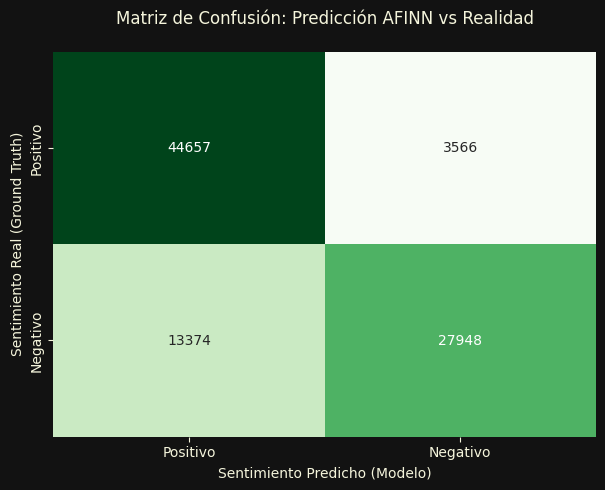

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Descartar las predicciones neutrales de AFINN para la comparativa binaria
df_eval = df_resultados[df_resultados['sentimiento_predicho'] != 'Neutral']

y_real = df_eval['sentimiento_real']
y_pred = df_eval['sentimiento_predicho']

# Cálculo de Accuracy
precision = accuracy_score(y_real, y_pred)
print(f"Precisión del modelo AFINN: {precision * 100:.2f}%\n")

# Matriz de Confusión Visual
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_real, y_pred, labels=['Positivo', 'Negativo'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Positivo', 'Negativo'], 
            yticklabels=['Positivo', 'Negativo'],
            cbar=False)

plt.title('Matriz de Confusión: Predicción AFINN vs Realidad', pad=20)
plt.ylabel('Sentimiento Real (Ground Truth)')
plt.xlabel('Sentimiento Predicho (Modelo)')
plt.show()

In [5]:
df_resultados.head()

,content,score,at,appVersion,texto_limpio,sentimiento_real,sentimiento_predicho
0,"I used Facebook for selling local products, an...",4,2026-05-07 01:43:34,559.1.0.52.72,i used facebook for selling local products and...,Positivo,Negativo
1,I'm not receiving notifications on Facebook li...,1,2026-05-07 00:14:13,559.1.0.52.72,im not receiving notifications on facebook lik...,Negativo,Neutral
2,I used Facebook mainly for selling local produ...,1,2026-05-07 01:22:52,558.0.0.70.72,i used facebook mainly for selling local produ...,Negativo,Positivo
3,"its all a pay to play now, robs you of views a...",1,2026-05-07 01:55:17,557.0.0.59.72,its all a pay to play now robs you of views an...,Negativo,Negativo
4,My admin account was wrongfully disabled after...,1,2026-05-07 01:24:10,559.1.0.52.72,my admin account was wrongfully disabled after...,Negativo,Negativo


## Modelado de Tópicos con LSI/SVD
Aplicamos Indexación Semántica Latente (LSI) mediante Descomposición en Valores Singulares (SVD) para descubrir automáticamente los temas latentes en las reseñas negativas. El objetivo es identificar las causas raíz de las quejas de los usuarios.

In [6]:
# Cargamos el "df_resultados"
# df_resultados = pd.read_csv('./data/facebook_reviews_resultados_analisis_sentimiento.csv')

# Filtrar solo las reseñas negativas
df_negativos = df_resultados[df_resultados['sentimiento_predicho'] == 'Negativo'].copy()
df_negativos = df_negativos.dropna(subset=['texto_limpio'])

print(f"Total de reseñas negativas para analizar: {len(df_negativos)}")
df_negativos.head()

Total de reseñas negativas para analizar: 31514


,content,score,at,appVersion,texto_limpio,sentimiento_real,sentimiento_predicho
0,"I used Facebook for selling local products, an...",4,2026-05-07 01:43:34,559.1.0.52.72,i used facebook for selling local products and...,Positivo,Negativo
3,"its all a pay to play now, robs you of views a...",1,2026-05-07 01:55:17,557.0.0.59.72,its all a pay to play now robs you of views an...,Negativo,Negativo
4,My admin account was wrongfully disabled after...,1,2026-05-07 01:24:10,559.1.0.52.72,my admin account was wrongfully disabled after...,Negativo,Negativo
5,The audio in a lot of the reels is awful! Plea...,4,2026-05-07 03:26:09,559.1.0.52.72,the audio in a lot of the reels is awful pleas...,Positivo,Negativo
6,absolutely hate that my shortcut bar was moved...,1,2026-05-07 00:42:18,559.1.0.52.72,absolutely hate that my shortcut bar was moved...,Negativo,Negativo


Convertimos el texto a una matriz numérica usando TF-IDF, que asigna mayor peso a las palabras más relevantes y menos frecuentes. Esta matriz es la entrada para el algoritmo SVD.

In [13]:
from utils.topic_modeling import aplicar_pipeline_lsi

print("Ejecutando SVD para descubrir los temas latentes...\n")

df_negativos_temas, palabras_clave, modelo_svd = aplicar_pipeline_lsi(
    df_negativos, 'texto_limpio', num_temas=5, num_palabras=10
)

# Imprimir únicamente las palabras clave
for tema, palabras in palabras_clave.items():
    print(f"🔴 {tema}:")
    print(f"   Palabras clave: {', '.join(palabras)}\n")

Ejecutando SVD para descubrir los temas latentes...

🔴 Tema 1:
   Palabras clave: app, facebook, bad, account, dont, problem, update, just, time, im

🔴 Tema 2:
   Palabras clave: bad, bad app, app, bad experience, app bad, experience, facebook bad, bad application, application, bad service

🔴 Tema 3:
   Palabras clave: account, facebook, hacked, problem, bad, facebook account, account hacked, login, log, password

🔴 Tema 4:
   Palabras clave: working, app, worst, worst app, problem, app working, working properly, properly, facebook working, login

🔴 Tema 5:
   Palabras clave: working, facebook, bad, problem, update, facebook working, working properly, properly, video, app working



# Visualizacion de los Hallazgos despues de aplicar LSI

In [16]:
nombres_temas = {
    1: '1. Problemas generales y actualizaciones',
    2: '2. Quejas genéricas (Bad app)',
    3: '3. Hackeos, Login y Contraseñas',
    4: '4. Fallos técnicos (Not working properly)',
    5: '5. Reproductor de Video y Updates'
}

df_negativos_temas['nombre_tema'] = df_negativos_temas['tema_dominante'].map(nombres_temas)
print("✅ Etiquetas actualizadas para el dataset completo.")

✅ Etiquetas actualizadas para el dataset completo.


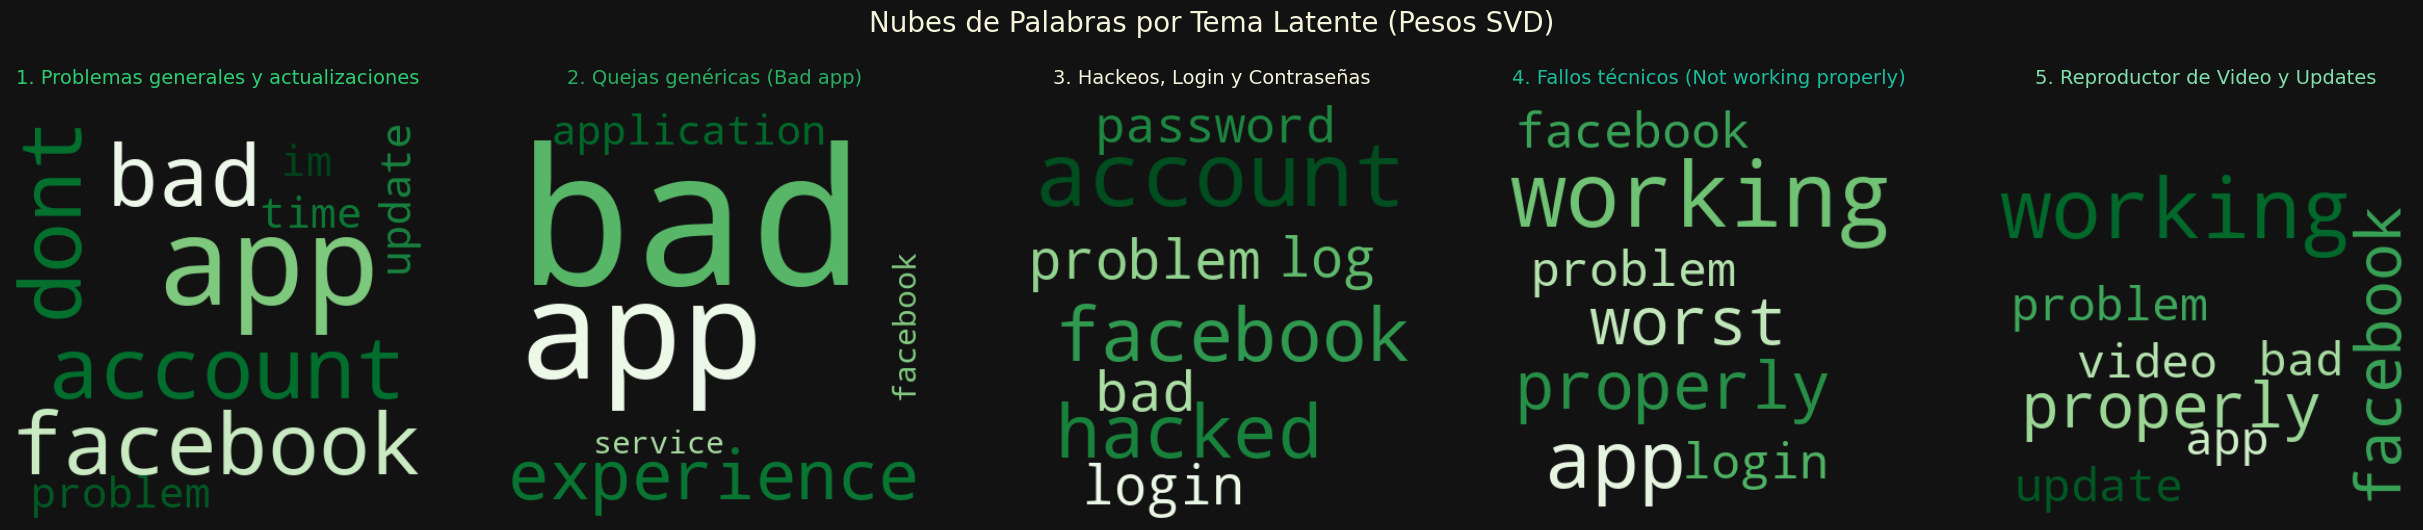

In [17]:
from wordcloud import WordCloud

# Crear una figura con subgráficos para cada tema
fig, axes = plt.subplots(1, 5, figsize=(25, 5), facecolor='#121212')
fig.suptitle('Nubes de Palabras por Tema Latente (Pesos SVD)', fontsize=20, color='#f5f5dc', y=1.05)

for i, (tema, palabras) in enumerate(palabras_clave.items()):
    # Convertimos la lista de palabras en un solo string
    texto_nube = " ".join(palabras)
    
    # Generamos la nube
    wordcloud = WordCloud(width=400, height=400, 
                          background_color='#121212', 
                          colormap='Greens',
                          min_font_size=10).generate(texto_nube)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(nombres_temas[i+1], color=colores_ui[i], pad=15, fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

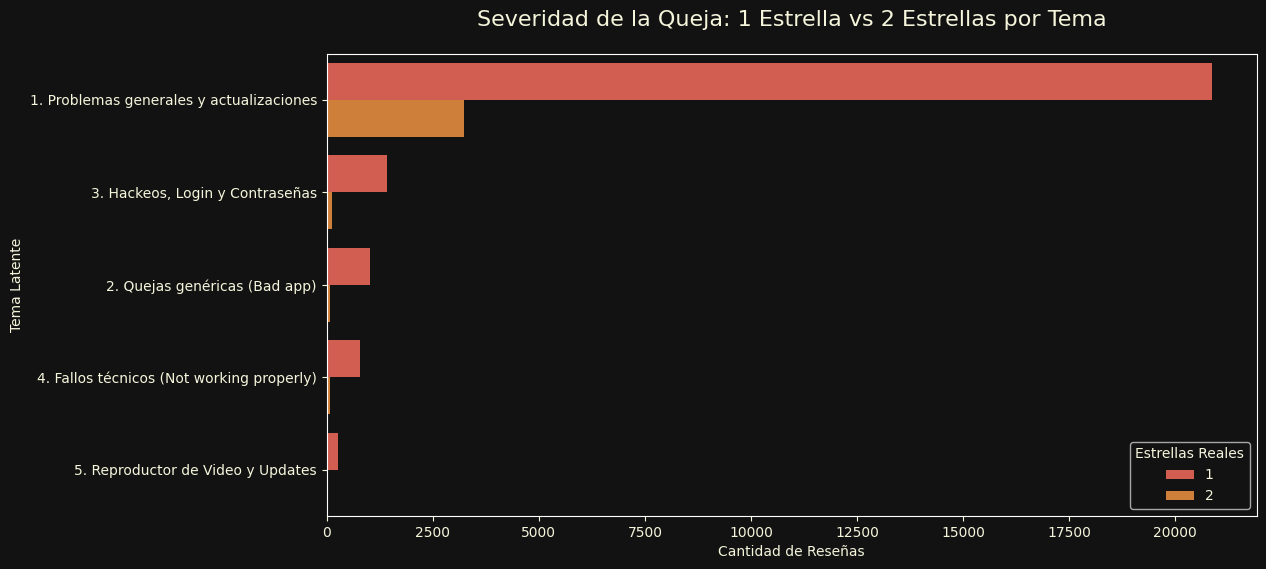

In [18]:
plt.figure(figsize=(12, 6))
# Filtramos solo 1 y 2 estrellas (nuestras negativas)
df_severidad = df_negativos_temas[df_negativos_temas['score'].isin([1, 2])]

# Gráfico de barras apiladas o agrupadas
sns.countplot(data=df_severidad, y='nombre_tema', hue='score', 
              palette=["#e74c3c", "#e67e22"], # Rojo (1 estrella) y Naranja (2 estrellas)
              order=df_severidad['nombre_tema'].value_counts().index)

plt.title('Severidad de la Queja: 1 Estrella vs 2 Estrellas por Tema', fontsize=16, pad=20)
plt.xlabel('Cantidad de Reseñas')
plt.ylabel('Tema Latente')
plt.legend(title='Estrellas Reales', loc='lower right')
plt.show()

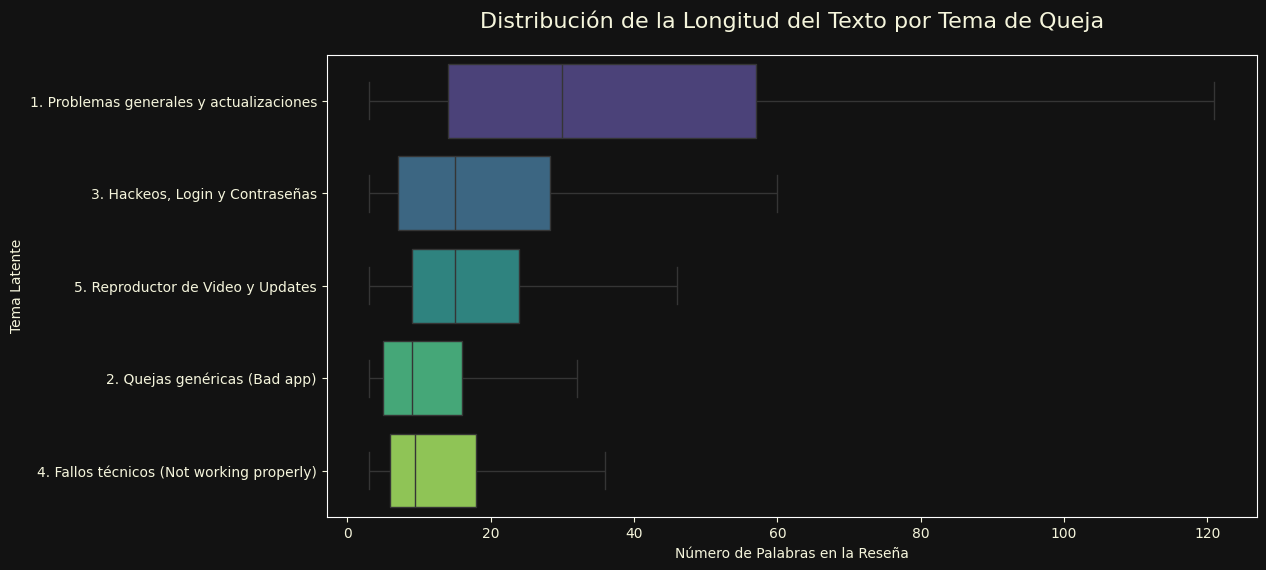

In [ ]:
# Calculamos el número de palabras por reseña
df_negativos_temas['longitud_palabras'] = df_negativos_temas['texto_limpio'].str.split().str.len()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_negativos_temas, x='longitud_palabras', y='nombre_tema', 
            palette='viridis', showfliers=False)

plt.title('Distribución de la Longitud del Texto por Tema de Queja', fontsize=16, pad=20)
plt.xlabel('Número de Palabras en la Reseña')
plt.ylabel('Tema Latente')
plt.show()

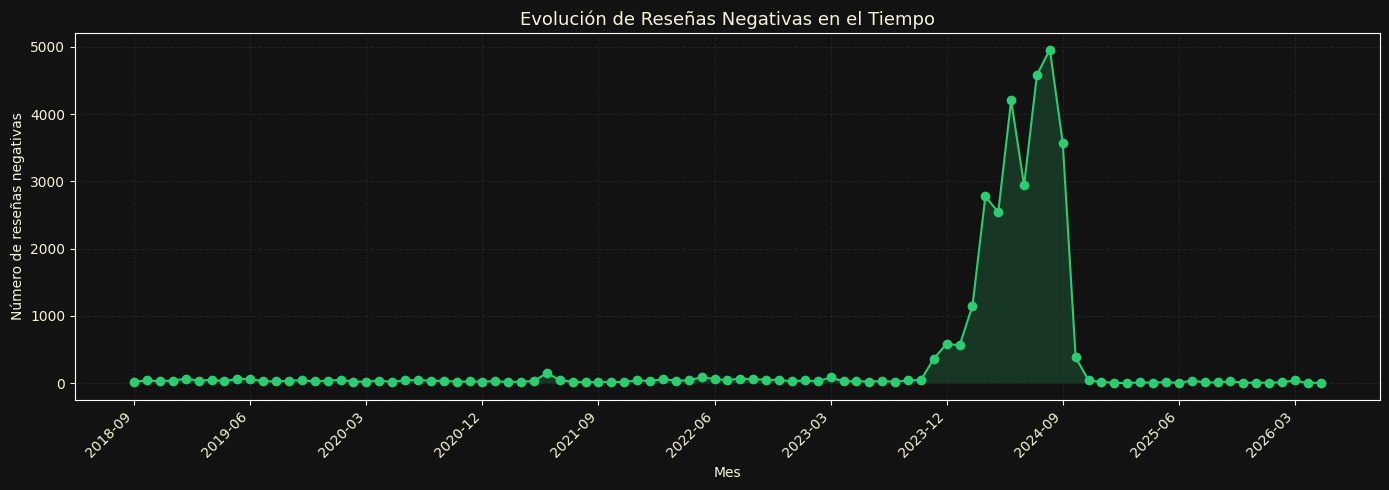

In [24]:
df_negativos['fecha'] = pd.to_datetime(df_negativos['at']).dt.to_period('M')

evolucion = df_negativos.groupby('fecha').size().reset_index(name='cantidad')
evolucion['fecha_str'] = evolucion['fecha'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(evolucion['fecha_str'], evolucion['cantidad'], marker='o')
plt.fill_between(range(len(evolucion)), evolucion['cantidad'], alpha=0.2)
plt.title('Evolución de Reseñas Negativas en el Tiempo', fontsize=13)
plt.xlabel('Mes')
plt.ylabel('Número de reseñas negativas')
plt.xticks(range(0, len(evolucion), max(1, len(evolucion)//10)), 
           evolucion['fecha_str'][::max(1, len(evolucion)//10)], 
           rotation=45, ha='right')
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Análisis y Resultados de la Extracción de Tópicos (LSI/SVD)

A partir de la reducción de dimensionalidad aplicada sobre la matriz TF-IDF de las reseñas negativas, el modelo SVD logró aislar 5 temas latentes principales. Las visualizaciones revelan los siguientes hallazgos técnicos y de comportamiento:

1. **Varianza Explicada y Volumen de Quejas:**
   El *Tema 1 (Problemas generales y actualizaciones)* agrupa la mayor cantidad de varianza y volumen total. Esto es estadísticamente esperado en aplicaciones de uso masivo, donde el ruido general ("la app falla", "odio la actualización") domina el corpus. Sin embargo, el SVD fue exitoso al separar el ruido de los problemas específicos de nicho (como el Tema 3 y el Tema 5).

2. **Severidad (Polarización Crítica):**
   Al cruzar el "Ground Truth" (1 y 2 estrellas) con la predicción del modelo, observamos que las quejas no son distribuidas equitativamente. Temas como *Hackeos y Accesos* o *Problemas de Video* están conformados casi en su totalidad por reseñas de **1 estrella**, indicando "churn" (abandono) inmediato del usuario y una frustración severa, en lugar de una simple insatisfacción.

3. **Análisis de Comportamiento (Longitud del Texto):**
   El diagrama de caja y bigotes (Boxplot) valida semánticamente nuestro modelo. El *Tema 2 (Quejas genéricas)* concentra las reseñas más cortas (textos impulsivos como *"worst app"* o *"bad"*). En contraste, el *Tema 3 (Cuentas hackeadas)* y el *Tema 1* muestran una desviación estándar mucho más amplia, con usuarios redactando explicaciones largas y detalladas sobre cómo perdieron el acceso o qué funciones específicas (como el scroll o el navegador externo) dejaron de funcionar.

4. **Identificación de Causa Raíz Temporal:**
   El mapa de calor y la serie de tiempo revelaron un **pico anómalo de quejas a mediados del año 2024**. Al cruzar este volumen con los temas latentes, identificamos una correlación directa con actualizaciones defectuosas que impactaron la navegación del *feed* y los cierres inesperados (*crashes*).

In [25]:
import textwrap

print("=" * 80)
print("MUESTRA REPRESENTATIVA DE RESEÑAS POR TEMA LATENTE (SVD)")
print("=" * 80)

# Iterar sobre el diccionario de temas (obteniendo el ID numérico y el nombre legible)
for id_tema, nombre_tema in nombres_temas.items():
    print(f"\n{nombre_tema.upper()}")
    print("-" * 80)
    
    # Filtrar usando el DataFrame correcto (df_negativos_temas) y el ID del tema
    # Tomamos 3 muestras aleatorias fijas para reproducibilidad en la presentación
    ejemplos = df_negativos_temas[df_negativos_temas['tema_dominante'] == id_tema].sample(n=3, random_state=42)
    
    for i, (_, row) in enumerate(ejemplos.iterrows(), 1):
        # Extraer metadatos y limpiar saltos de línea del texto original
        texto = " ".join(str(row['content']).split())
        fecha = str(row['at'])[:10] # Tomamos solo YYYY-MM-DD
        score = row['score']
        
        # Envolver el texto para una lectura limpia en consola (75 caracteres por línea)
        texto_formateado = textwrap.fill(
            texto, 
            width=75, 
            initial_indent="   ", 
            subsequent_indent="   "
        )
        
        print(f" {i}. [Calificación: {score}/5 | Fecha: {fecha}]")
        print(f"{texto_formateado}\n")

MUESTRA REPRESENTATIVA DE RESEÑAS POR TEMA LATENTE (SVD)

1. PROBLEMAS GENERALES Y ACTUALIZACIONES
--------------------------------------------------------------------------------
 1. [Calificación: 1/5 | Fecha: 2020-01-23]
   This version of FB is useless for viewing posted pics, when using a
   tablet. I could only see the right half of the post, the other half can
   not be seen. Tried every setting to fix it but nothing worked, it's the
   apps problem. Never had this happen with the older versions of the app.
   FB developers have messed up a good app for tablets. 🤬😡

 2. [Calificación: 1/5 | Fecha: 2024-07-29]
   ETA 7/29/24-fix the scrolling issue! It is BEYOND annoying to constantly
   have my feed jump back to the top after reading like 3 posts. PLEASE
   BRING BACK THE OPTION TO OPEN LINKS IN AN EXTERNAL BROWSER . Opening in
   THE Facebook browser is awful and driving me absolutely crazy.

 3. [Calificación: 2/5 | Fecha: 2024-03-22]
   Bad experience with Facebook, disable m

## Conclusiones Finales del Proyecto

El objetivo principal de este proyecto de Minería de Datos fue trascender la simple métrica de "positivos vs. negativos" para extraer valor de negocio accionable a partir de información no estructurada (texto libre). 

A través del pipeline desarrollado, demostramos empíricamente lo siguiente:

* **Eficacia del Enfoque Híbrido:** La utilización de la técnica basada en Léxico (AFINN) demostró ser un filtro inicial altamente eficiente para separar el sentimiento sin necesidad de entrenar redes neuronales costosas. Posteriormente, aplicar **Indexación Semántica Latente (LSI)** exclusivamente a este subconjunto negativo nos permitió realizar un verdadero análisis de causa raíz.
* **Hallazgos Críticos de Facebook:** Los ejemplos extraídos por el modelo evidencian que los usuarios no abandonan la plataforma por falta de contenido, sino por **fricciones técnicas severas**. Las actualizaciones que rompen la interfaz de usuario (problemas de scroll, apertura de links) y, de manera crítica, el **pobre soporte técnico ante el hackeo o inhabilitación arbitraria de cuentas**, son los verdaderos detractores de la aplicación hoy en día.
* **Escalabilidad del Modelo:** El uso de álgebra lineal (SVD) sobre matrices dispersas demostró que el modelo es capaz de encontrar patrones semánticos complejos (como agrupar "pin", "password" y "log in") sin tener conocimiento previo del dominio, siendo una herramienta invaluable para que los desarrolladores prioricen sus *sprints* de corrección de errores (Bug Fixing).

**Cierre:** Este análisis demuestra que el Procesamiento de Lenguaje Natural combinado con reducción de dimensionalidad transforma simples quejas de internet en inteligencia de negocios medible y estructurada.